# 07 — Evaluation Synthesis

Consolidates frozen outputs from `04_classifier`, `05_retrieval`, and `06_agent`
into an end-to-end view of the ResolveIQ pipeline on the golden test set.

## What this notebook does

- Reads frozen artifacts only
- Verifies upstream TEST_LOCK files (04, 05) and EVAL_LOCK (06)
- Produces end-to-end success metrics, cascade attribution, slice breakdowns
- Emits report-ready tables, figures, and `limitations.md`
- Writes `runs/evaluation/metrics.json` as the single source of truth

## What this notebook does NOT do

- Re-run classification, retrieval, generation, or judging
- Tune anything against test
- Recompute calibration or any value already frozen upstream
- Modify any artifact in `runs/classifier/`, `runs/retrieval/`, `runs/agent/`

## Four headline numbers (not one)

1. **Intent quality** — classifier op macro F1 (test)
2. **Retrieval quality** — recall@5 (test) + human audit nDCG (dev)
3. **Reply quality** — mean universal score + unsupported-claim rate (test)
4. **Safe automation coverage** — % of test traffic handled correctly *and*
   with a good reply *and* not flagged unsafe

Plus: **unsafe automation rate** as the safety-gate number.

In [7]:
# ============ CELL 1b: Bootstrap ============
from pathlib import Path
import os, json, hashlib, sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_root():
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if (parent / "pyproject.toml").exists() or (parent / ".git").exists():
            return parent
    raise RuntimeError("Project root not found")

PROJECT_ROOT = _find_root()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CONFIG_DIR      = PROJECT_ROOT / "configs"
TAX_DIR         = PROJECT_ROOT / "runs" / "taxonomy"
GS_DIR          = PROJECT_ROOT / "runs" / "golden_set"
RUNS_CLASSIFIER = PROJECT_ROOT / "runs" / "classifier"
RUNS_RETRIEVAL  = PROJECT_ROOT / "runs" / "retrieval"
RUNS_AGENT      = PROJECT_ROOT / "runs" / "agent"
RUNS_EVAL       = PROJECT_ROOT / "runs" / "evaluation"
REPORTS_FIGS    = PROJECT_ROOT / "reports" / "figures"

for d in (RUNS_EVAL, REPORTS_FIGS):
    d.mkdir(parents=True, exist_ok=True)

print("Bootstrap complete.")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  RUNS_EVAL:    {RUNS_EVAL.relative_to(PROJECT_ROOT)}")

Bootstrap complete.
  PROJECT_ROOT: D:\CODIN PLAYGROUND\ML-AI\ResolveIQ
  RUNS_EVAL:    runs\evaluation


In [8]:
# ============ CELL 2: Verify all frozen inputs ============
import yaml

# --- Paths ---
INTENTS_YAML  = CONFIG_DIR / "intents.yaml"
INTENTS_SHA_F = TAX_DIR / "intents.yaml.sha256"
GOLDEN_JSONL  = GS_DIR / "golden_set.jsonl"
GOLDEN_SHA_F  = GS_DIR / "golden_set.sha256"
GOLDEN_META   = GS_DIR / "golden_set.meta.json"

CLS_CHOSEN    = RUNS_CLASSIFIER / "chosen.json"
CLS_TEST      = RUNS_CLASSIFIER / "predictions_test.jsonl"
CLS_FINAL     = RUNS_CLASSIFIER / "final_metrics.json"
CLS_LOCK      = RUNS_CLASSIFIER / "TEST_LOCK.json"

RET_CHOSEN    = RUNS_RETRIEVAL / "chosen_retriever.json"
RET_TEST      = RUNS_RETRIEVAL / "predictions_test.jsonl"
RET_FINAL     = RUNS_RETRIEVAL / "final_metrics.json"
RET_LOCK      = RUNS_RETRIEVAL / "TEST_LOCK.json"
RET_CORPUS    = RUNS_RETRIEVAL / "corpus.jsonl"

AGENT_CHOSEN  = RUNS_AGENT / "chosen_agent.json"
AGENT_TEST    = RUNS_AGENT / "predictions_test.jsonl"
AGENT_FINAL   = RUNS_AGENT / "final_metrics.json"
AGENT_EVLOCK  = RUNS_AGENT / "EVAL_LOCK.json"
AGENT_UNI     = RUNS_AGENT / "universal_scores_test.jsonl"
AGENT_ESC     = RUNS_AGENT / "escalation_suitability_test.jsonl"

REQUIRED = [
    INTENTS_YAML, INTENTS_SHA_F, GOLDEN_JSONL, GOLDEN_SHA_F, GOLDEN_META,
    CLS_CHOSEN, CLS_TEST, CLS_FINAL, CLS_LOCK,
    RET_CHOSEN, RET_TEST, RET_FINAL, RET_LOCK, RET_CORPUS,
    AGENT_CHOSEN, AGENT_TEST, AGENT_FINAL, AGENT_EVLOCK, AGENT_UNI, AGENT_ESC,
]
for p in REQUIRED:
    assert p.exists(), f"Missing required input: {p}"

def _sha(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def _find_key(d, candidates):
    """Return the first candidate key present in dict d, or None."""
    for k in candidates:
        if k in d:
            return k
    return None

# --- Taxonomy ---
tax_sha = _sha(INTENTS_YAML)
assert tax_sha == INTENTS_SHA_F.read_text(encoding="utf-8").strip(), \
    "Taxonomy SHA mismatch"
tax = yaml.safe_load(INTENTS_YAML.read_bytes())
assert tax.get("draft") is False, "Taxonomy is still draft"
INTENT_NAMES = [i["name"] for i in tax["intents"]]

# --- Golden ---
golden_sha = _sha(GOLDEN_JSONL)
golden_meta = json.loads(GOLDEN_META.read_text(encoding="utf-8"))
assert golden_sha == golden_meta["golden_sha256"]
assert golden_sha == GOLDEN_SHA_F.read_text(encoding="utf-8").strip()
assert golden_meta["taxonomy_sha256"] == tax_sha
GOLDEN_TEST_IDS = set(int(x) for x in golden_meta["test_root_ids"])

# --- Chosen configs ---
cls_chosen = json.loads(CLS_CHOSEN.read_text(encoding="utf-8"))
cls_chosen_sha = _sha(CLS_CHOSEN)
assert cls_chosen["taxonomy_sha256"] == tax_sha
assert cls_chosen["golden_sha256"]   == golden_sha

ret_chosen = json.loads(RET_CHOSEN.read_text(encoding="utf-8"))
ret_chosen_sha = _sha(RET_CHOSEN)
assert ret_chosen["taxonomy_sha256"]   == tax_sha
assert ret_chosen["golden_sha256"]     == golden_sha
assert ret_chosen["classifier_sha256"] == cls_chosen_sha
CORPUS_SHA = _sha(RET_CORPUS)
assert ret_chosen["corpus_sha256"] == CORPUS_SHA

agent_chosen = json.loads(AGENT_CHOSEN.read_text(encoding="utf-8"))
agent_chosen_sha = _sha(AGENT_CHOSEN)
assert agent_chosen["taxonomy_sha256"]   == tax_sha
assert agent_chosen["golden_sha256"]     == golden_sha
assert agent_chosen["classifier_sha256"] == cls_chosen_sha
assert agent_chosen["retriever_sha256"]  == ret_chosen_sha
assert agent_chosen["corpus_sha256"]     == CORPUS_SHA

# ---------------------------------------------------------------
# 04 TEST_LOCK verification — flexible schema
# ---------------------------------------------------------------
cls_lock = json.loads(CLS_LOCK.read_text(encoding="utf-8"))
print(f"04 TEST_LOCK keys: {list(cls_lock.keys())}")

_chosen_key = _find_key(cls_lock, ["chosen_sha", "chosen_agent_sha",
                                    "chosen_classifier_sha",
                                    "chosen_approach_sha"])
if _chosen_key is not None:
    assert cls_lock[_chosen_key] == cls_chosen_sha, \
        f"04 TEST_LOCK chosen mismatch: " \
        f"{cls_lock[_chosen_key][:16]} vs {cls_chosen_sha[:16]}"
    print(f"  ✓ chosen SHA verified")
else:
    print(f"  ⚠ no chosen-sha key found in 04 TEST_LOCK")

_preds_key = _find_key(cls_lock, ["predictions_sha256", "test_preds_sha256",
                                   "predictions_test_sha256", "preds_sha256"])
if _preds_key is not None:
    actual = _sha(CLS_TEST)
    assert actual == cls_lock[_preds_key], \
        f"04 predictions_test.jsonl changed since TEST_LOCK"
    print(f"  ✓ predictions SHA verified")
else:
    print(f"  ⚠ no predictions SHA in 04 TEST_LOCK — relying on ID-set equality")

_metrics_key = _find_key(cls_lock, ["metrics_sha256", "final_metrics_sha256"])
if _metrics_key is not None:
    assert _sha(CLS_FINAL) == cls_lock[_metrics_key], \
        "04 final_metrics.json changed since TEST_LOCK"
    print(f"  ✓ metrics SHA verified")

# ---------------------------------------------------------------
# 05 TEST_LOCK verification — flexible schema
# ---------------------------------------------------------------
ret_lock = json.loads(RET_LOCK.read_text(encoding="utf-8"))
print(f"\n05 TEST_LOCK keys: {list(ret_lock.keys())}")

_chosen_key = _find_key(ret_lock, ["chosen_sha", "chosen_retriever_sha",
                                    "retriever_sha"])
if _chosen_key is not None:
    assert ret_lock[_chosen_key] == ret_chosen_sha, \
        f"05 TEST_LOCK chosen mismatch"
    print(f"  ✓ chosen SHA verified")
else:
    print(f"  ⚠ no chosen-sha key found in 05 TEST_LOCK")

_preds_key = _find_key(ret_lock, ["predictions_sha256", "test_preds_sha256",
                                   "predictions_test_sha256", "preds_sha256"])
if _preds_key is not None:
    assert _sha(RET_TEST) == ret_lock[_preds_key], \
        "05 predictions_test.jsonl changed since TEST_LOCK"
    print(f"  ✓ predictions SHA verified")
else:
    print(f"  ⚠ no predictions SHA in 05 TEST_LOCK — relying on ID-set equality")

_metrics_key = _find_key(ret_lock, ["metrics_sha256", "final_metrics_sha256"])
if _metrics_key is not None:
    assert _sha(RET_FINAL) == ret_lock[_metrics_key], \
        "05 final_metrics.json changed since TEST_LOCK"
    print(f"  ✓ metrics SHA verified")

_corpus_key = _find_key(ret_lock, ["corpus_sha256"])
if _corpus_key is not None:
    assert _sha(RET_CORPUS) == ret_lock[_corpus_key], \
        "05 corpus.jsonl changed since TEST_LOCK"
    print(f"  ✓ corpus SHA verified")

# ---------------------------------------------------------------
# 06 EVAL_LOCK verification
# ---------------------------------------------------------------
EVAL_LOCK_MAP = {
    "chosen_agent":                AGENT_CHOSEN,
    "predictions_test":            AGENT_TEST,
    "test_lock":                   RUNS_AGENT / "TEST_LOCK.json",
    "escalation_suitability_test": AGENT_ESC,
    "universal_scores_test":       AGENT_UNI,
    "final_metrics":               AGENT_FINAL,
    "groundedness_scores_test":    RUNS_AGENT / "groundedness_scores_test.jsonl",
}
eval_lock = json.loads(AGENT_EVLOCK.read_text(encoding="utf-8"))
print(f"\n06 EVAL_LOCK keys: {list(eval_lock['artifacts'].keys())}")
for name, recorded in eval_lock["artifacts"].items():
    path = EVAL_LOCK_MAP.get(name)
    if path is None:
        continue
    if not path.exists():
        if name == "groundedness_scores_test":
            continue
        raise FileNotFoundError(f"{name}: {path} missing")
    actual = _sha(path)
    assert actual == recorded, \
        f"06 EVAL_LOCK mismatch for {name}:\n" \
        f"  recorded: {recorded[:16]}\n  actual:   {actual[:16]}"
print(f"  ✓ EVAL_LOCK verified for all present artifacts")

# ---------------------------------------------------------------
# ID set equality across all three test prediction files
# ---------------------------------------------------------------
def _test_ids(path):
    ids = set()
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            ids.add(int(json.loads(line)["root_id"]))
    return ids

assert _test_ids(CLS_TEST)   == GOLDEN_TEST_IDS, "Classifier test IDs ≠ golden"
assert _test_ids(RET_TEST)   == GOLDEN_TEST_IDS, "Retriever test IDs ≠ golden"
assert _test_ids(AGENT_TEST) == GOLDEN_TEST_IDS, "Agent test IDs ≠ golden"

print()
print("✓ All frozen inputs verified")
print(f"  Taxonomy SHA:     {tax_sha[:16]}...")
print(f"  Golden SHA:       {golden_sha[:16]}...")
print(f"  Classifier SHA:   {cls_chosen_sha[:16]}...")
print(f"  Retriever SHA:    {ret_chosen_sha[:16]}...")
print(f"  Agent SHA:        {agent_chosen_sha[:16]}...")
print(f"  Corpus SHA:       {CORPUS_SHA[:16]}...")
print(f"  Test root_ids:    {len(GOLDEN_TEST_IDS)}")

04 TEST_LOCK keys: ['chosen_sha', 'test_preds_sha256', 'evaluated_at']
  ✓ chosen SHA verified
  ✓ predictions SHA verified

05 TEST_LOCK keys: ['chosen_sha', 'corpus_sha256', 'predictions_sha256', 'metrics_sha256', 'evaluated_at']
  ✓ chosen SHA verified
  ✓ predictions SHA verified
  ✓ metrics SHA verified
  ✓ corpus SHA verified

06 EVAL_LOCK keys: ['chosen_agent', 'predictions_test', 'test_lock', 'escalation_suitability_test', 'universal_scores_test', 'final_metrics']
  ✓ EVAL_LOCK verified for all present artifacts

✓ All frozen inputs verified
  Taxonomy SHA:     7a05e4af68a50981...
  Golden SHA:       acde341dc09e85ae...
  Classifier SHA:   7d51251a172e623c...
  Retriever SHA:    33dbaea4a95ad148...
  Agent SHA:        dc6c09f6f3cd147e...
  Corpus SHA:       69327018136200df...
  Test root_ids:    139


In [9]:
# ============ CELL 3: Load frozen TEST artifacts ============
cls_test   = pd.read_json(CLS_TEST, orient="records", lines=True)
ret_test   = pd.read_json(RET_TEST, orient="records", lines=True)
agent_test = pd.read_json(AGENT_TEST, orient="records", lines=True)
uni_test   = pd.read_json(AGENT_UNI, orient="records", lines=True)
esc_test   = pd.read_json(AGENT_ESC, orient="records", lines=True)

GRD_PATH = RUNS_AGENT / "groundedness_scores_test.jsonl"
grd_test = pd.read_json(GRD_PATH, orient="records", lines=True) \
           if GRD_PATH.exists() else None

# --- One-row-per-root validation ---
for name, df in [("cls", cls_test), ("ret", ret_test), ("agent", agent_test),
                 ("uni", uni_test), ("esc", esc_test)]:
    assert df["root_id"].is_unique, f"{name}: root_id not unique"

# --- ID set consistency ---
cls_ids   = set(cls_test["root_id"].astype(int))
ret_ids   = set(ret_test["root_id"].astype(int))
agent_ids = set(agent_test["root_id"].astype(int))
uni_ids   = set(uni_test["root_id"].astype(int))
esc_ids   = set(esc_test["root_id"].astype(int))

assert cls_ids == ret_ids == agent_ids, "ID sets diverge across cls/ret/agent"
assert cls_ids == uni_ids, "Universal judge IDs ≠ classifier IDs"
assert cls_ids == esc_ids, "Escalation judge IDs ≠ classifier IDs"
assert cls_ids == GOLDEN_TEST_IDS, "IDs ≠ golden test IDs"

# --- Ground-truth consistency across artifacts ---
truth = (cls_test[["root_id", "true_intent", "_source"]]
         .rename(columns={"true_intent": "true_intent_cls",
                          "_source": "_source_cls"}))

for name, df in [("ret", ret_test), ("agent", agent_test)]:
    if "true_intent" in df.columns and "_source" in df.columns:
        joined = df[["root_id", "true_intent", "_source"]].merge(
            truth, on="root_id", how="inner")
        assert joined["true_intent"].eq(joined["true_intent_cls"]).all(), \
            f"{name}: true_intent diverges from classifier"
        assert joined["_source"].eq(joined["_source_cls"]).all(), \
            f"{name}: _source diverges from classifier"

# --- Frozen summaries ---
cls_final = json.loads(CLS_FINAL.read_text(encoding="utf-8"))
ret_final = json.loads(RET_FINAL.read_text(encoding="utf-8"))
ag_final  = json.loads(AGENT_FINAL.read_text(encoding="utf-8"))

print(f"classifier test predictions:  {len(cls_test)} rows")
print(f"retriever  test predictions:  {len(ret_test)} rows")
print(f"agent      test predictions:  {len(agent_test)} rows")
print(f"universal  judge scores:      {len(uni_test)} rows")
print(f"escalation judge labels:      {len(esc_test)} rows")
if grd_test is not None:
    print(f"groundedness judge scores:    {len(grd_test)} rows")

print(f"\nChosen classifier:  {cls_final['approach']}")
print(f"Chosen retriever:   {ret_final['approach']}")
print(f"Chosen agent:       {ag_final['chosen_approach']}")

classifier test predictions:  139 rows
retriever  test predictions:  139 rows
agent      test predictions:  139 rows
universal  judge scores:      139 rows
escalation judge labels:      139 rows

Chosen classifier:  llm_zeroshot
Chosen retriever:   tfidf
Chosen agent:       ungrounded


In [14]:
# ============ CELL 4: Canonical end-to-end table ============
# agent_test already carries most fields. We only ADD what's missing.

def _subset(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()

end = agent_test.copy()

# --- Retriever fields: add retrieval_mrr and retrieval_recall@5 if missing ---
if "retrieval_mrr" not in end.columns and "mrr" in ret_test.columns:
    r = _subset(ret_test, ["root_id", "mrr", "recall@5"]).rename(
        columns={"mrr": "retrieval_mrr", "recall@5": "retrieval_recall@5"}
    )
    end = end.merge(r, on="root_id", how="left")
    print("Added retrieval_mrr and retrieval_recall@5")

# --- Universal judge ---
if "universal_score" not in end.columns:
    end = end.merge(
        _subset(uni_test, ["root_id", "universal_score", "unsupported_claim",
                            "correctness", "relevance", "helpfulness"]),
        on="root_id", how="left",
    )
    print("Added universal judge fields")

# --- Escalation judge ---
if "auto_handle_safe" not in end.columns:
    end = end.merge(
        _subset(esc_test, ["root_id", "auto_handle_safe"]),
        on="root_id", how="left",
    )
    print("Added auto_handle_safe")

# --- Drop any unexpected _x/_y suffixes from previous merges ---
drop_cols = [c for c in end.columns if c.endswith(("_x", "_y"))]
if drop_cols:
    end = end.drop(columns=drop_cols)
    print(f"Dropped suffix columns: {drop_cols}")

print(f"Columns: {end.columns.tolist()}")

# --- Validate ---
REQUIRED_COLS = [
    "root_id", "customer_text", "true_intent", "pred_intent",
    "confidence", "corpus_coverage", "escalated", "auto_handle_safe",
    "universal_score", "unsupported_claim", "reply",
]
missing = [c for c in REQUIRED_COLS if c not in end.columns]
assert not missing, f"Missing required columns after merge: {missing}"

assert len(end) == 139, f"Expected 139 rows, got {len(end)}"
assert end["escalated"].notna().all()
assert end["auto_handle_safe"].notna().all()
assert end["corpus_coverage"].notna().all()

end["escalated"]         = end["escalated"].astype(bool)
end["auto_handle_safe"]  = end["auto_handle_safe"].astype(bool)
end["unsupported_claim"] = end["unsupported_claim"].fillna(False).astype(bool)

end["classifier_correct"] = (end["true_intent"] == end["pred_intent"])
end["margin"] = end["confidence"] - end["alternative_confidence"].fillna(0.0)
end["reply_good"] = end["universal_score"].notna() & (end["universal_score"] >= 12)

# Sanity
print(f"\nEscalated with universal_score: "
      f"{int((end['escalated'] & end['universal_score'].notna()).sum())} (expect 0)")
print(f"Auto-handled without universal_score: "
      f"{int(((~end['escalated']) & end['universal_score'].isna()).sum())} (expect 0)")

end.to_json(RUNS_EVAL / "end_to_end_test.jsonl",
            orient="records", lines=True, force_ascii=False)

print(f"\nCanonical table: {len(end)} rows, {end.shape[1]} columns")
print(f"Classifier accuracy: {end['classifier_correct'].mean():.3f}")
print(f"Auto-handle safe:    {end['auto_handle_safe'].mean():.3f}")
print(f"Escalated:           {end['escalated'].mean():.3f}")

Added retrieval_mrr and retrieval_recall@5
Added universal judge fields
Added auto_handle_safe
Columns: ['root_id', 'customer_text', 'true_intent', 'pred_intent', 'confidence', 'confidence_calibrated', 'alternative_intent', 'alternative_confidence', 'corpus_coverage', 'retrieved_doc_ids', 'retrieval_scores', '_source', 'escalated', 'escalation_reason', 'reply', 'used_precedent_ranks', 'grounded', 'api_status', 'retrieval_mrr', 'retrieval_recall@5', 'universal_score', 'unsupported_claim', 'correctness', 'relevance', 'helpfulness', 'auto_handle_safe']

Escalated with universal_score: 0 (expect 0)
Auto-handled without universal_score: 0 (expect 0)

Canonical table: 139 rows, 29 columns
Classifier accuracy: 0.604
Auto-handle safe:    0.403
Escalated:           0.000


In [15]:
# ============ CELL 5: Headline metrics ============
def bootstrap_ci(values, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n == 0:
        return (0.0, 0.0)
    scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        scores[b] = values[idx].mean()
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

# ============================================================
# Q1 — Grounding ablation (DEV), derived from comparison_dev.csv
# ============================================================
cmp_dev = pd.read_csv(RUNS_AGENT / "comparison_dev.csv", encoding="utf-8")
ung = cmp_dev[cmp_dev["approach"] == "ungrounded"]
gnd = cmp_dev[cmp_dev["approach"] == "grounded_no_escalate"]
assert len(ung) == 1 and len(gnd) == 1, \
    "comparison_dev.csv must have one ungrounded and one grounded row"

_ung_quality = float(ung["mean_auto_reply_quality"].iloc[0])
_gnd_quality = float(gnd["mean_auto_reply_quality"].iloc[0])
delta_grounding   = _gnd_quality - _ung_quality
delta_unsupported = float(ung["unsupported_rate"].iloc[0]
                          - gnd["unsupported_rate"].iloc[0])

# ============================================================
# Q2 — Final generation quality (TEST, over auto-handled replies only)
# ============================================================
reply_rows = end[(~end["escalated"]) & end["universal_score"].notna()]
mean_universal = float(reply_rows["universal_score"].mean())
unsup_rate     = float(reply_rows["unsupported_claim"].mean())
reply_n        = int(len(reply_rows))

# ============================================================
# Q3 — Automation safety (TEST)
# ============================================================
auto = end[end["escalated"] == False]
auto_n = int(len(auto))

safe_auto = auto[
    (auto["auto_handle_safe"] == True) &
    (auto["reply_good"] == True) &
    (auto["unsupported_claim"] == False)
]
safe_auto_coverage = len(safe_auto) / len(end)

unsafe_auto = auto[auto["auto_handle_safe"] == False]
unsafe_auto_rate = len(unsafe_auto) / auto_n if auto_n else 0.0

handled_correctly = (
    end["classifier_correct"] &
    (
        ((end["escalated"] == True) & (end["auto_handle_safe"] == False)) |
        ((end["escalated"] == False) & (end["auto_handle_safe"] == True) &
         (end["reply_good"] == True) & (end["unsupported_claim"] == False))
    )
)
safe_handling_rate = float(handled_correctly.mean())

# Decision matrix
should_esc = end["auto_handle_safe"] == False
did_esc    = end["escalated"] == True
tp = int((should_esc &  did_esc).sum())
fp = int((~should_esc & did_esc).sum())
tn = int((~should_esc & ~did_esc).sum())
fn = int(( should_esc & ~did_esc).sum())
escalation_precision = tp / (tp + fp) if (tp + fp) else None
escalation_recall    = tp / (tp + fn) if (tp + fn) else None
decision_accuracy    = (tp + tn) / len(end)

# ============================================================
# Bootstrap CIs
# ============================================================
ci_class_acc     = bootstrap_ci(end["classifier_correct"].astype(int).values)
ci_retrieval_r5  = bootstrap_ci(end["retrieval_recall@5"].values)
ci_universal     = bootstrap_ci(reply_rows["universal_score"].values)
ci_safe_auto_cov = bootstrap_ci(
    ((auto["auto_handle_safe"] == True) &
     (auto["reply_good"] == True) &
     (auto["unsupported_claim"] == False))
    .reindex(end.index, fill_value=False).astype(int).values
)
ci_unsafe_auto   = bootstrap_ci(
    (auto["auto_handle_safe"] == False).astype(int).values
)
ci_safe_handling = bootstrap_ci(handled_correctly.astype(int).values)

# ============================================================
# Print headline block
# ============================================================
print("=" * 72)
print("FINAL SYSTEM")
print("=" * 72)
print(f"  Classifier:            {cls_final['approach']}")
print(f"  Retriever:             {ret_final['approach']}")
print(f"  Agent:                 {ag_final['chosen_approach']}")
print(f"  Generator model:       {agent_chosen.get('generator_model', 'n/a')}")
print(f"  Judge model:           {agent_chosen.get('judge_model', 'n/a')}")
print(f"  Escalation thresholds: {agent_chosen.get('escalation_config', {})}")
print(f"  Taxonomy:              v{tax.get('version', '?')}")
print(f"  Test size:             {len(end)}")
print()
print("=" * 72)
print("Q1 — Grounding ablation (DEV)")
print("=" * 72)
print(f"  Δ mean auto-reply quality (B − A): {delta_grounding:+.3f}")
print(f"  Δ unsupported-claim rate (A − B):  {delta_unsupported:+.3f}")
print()
print("=" * 72)
print(f"Q2 — Final generation quality (TEST, n_replies={reply_n})")
print("=" * 72)
print(f"  Mean universal score:    {mean_universal:.3f}  "
      f"95% CI [{ci_universal[0]:.3f}, {ci_universal[1]:.3f}]")
print(f"  Unsupported-claim rate:  {unsup_rate:.3f}")
print()
print("=" * 72)
print(f"Q3 — Automation safety (TEST, n_auto={auto_n})")
print("=" * 72)
print(f"  Automation coverage:       {auto_n/len(end):.3f}  (denom {len(end)})")
print(f"  Safe automation coverage:  {safe_auto_coverage:.3f}  "
      f"95% CI [{ci_safe_auto_cov[0]:.3f}, {ci_safe_auto_cov[1]:.3f}]")
print(f"  Unsafe automation rate:    {unsafe_auto_rate:.3f}  "
      f"95% CI [{ci_unsafe_auto[0]:.3f}, {ci_unsafe_auto[1]:.3f}]  "
      f"(denom {auto_n})")
print(f"  Escalation precision:      {escalation_precision}")
print(f"  Escalation recall:         {escalation_recall}")
print(f"  Decision accuracy:         {decision_accuracy:.3f}")
print()
print("=" * 72)
print("Pipeline success (two views)")
print("=" * 72)
print(f"  Safe-handling rate:        {safe_handling_rate:.3f}  "
      f"95% CI [{ci_safe_handling[0]:.3f}, {ci_safe_handling[1]:.3f}]")
print(f"  Safe-automation rate:      {safe_auto_coverage:.3f}")
print()
print("=" * 72)
print("Upstream headlines")
print("=" * 72)
print(f"  Classifier op macro F1:    {cls_final['operational']['macro_f1']:.3f}")
print(f"  Retrieval recall@5:        {ret_final['metrics']['recall@5']:.3f}")

FINAL SYSTEM
  Classifier:            llm_zeroshot
  Retriever:             tfidf
  Agent:                 ungrounded
  Generator model:       openai/gpt-oss-20b
  Judge model:           openai/gpt-oss-120b
  Escalation thresholds: {'tau_c': 0.4, 'tau_m': 0.15, 'escalate_on_other_or_ambiguous': True, 'escalate_on_zero_coverage': True}
  Taxonomy:              v1
  Test size:             139

Q1 — Grounding ablation (DEV)
  Δ mean auto-reply quality (B − A): -0.508
  Δ unsupported-claim rate (A − B):  -0.288

Q2 — Final generation quality (TEST, n_replies=139)
  Mean universal score:    13.374  95% CI [13.144, 13.597]
  Unsupported-claim rate:  0.194

Q3 — Automation safety (TEST, n_auto=139)
  Automation coverage:       1.000  (denom 139)
  Safe automation coverage:  0.295  95% CI [0.216, 0.374]
  Unsafe automation rate:    0.597  95% CI [0.511, 0.683]  (denom 139)
  Escalation precision:      None
  Escalation recall:         0.0
  Decision accuracy:         0.403

Pipeline success (t

In [16]:
# ============ CELL 6: Cascade analysis ============
def automation_cascade(row):
    """First failure of the auto-handling path."""
    if row["escalated"]:
        return "not_auto_handled"
    if not row["classifier_correct"]:
        return "1_classification"
    if int(row["corpus_coverage"]) == 0:
        return "2_retrieval_corpus_missing"
    if not row["auto_handle_safe"]:
        return "3_unsafe_auto_handle"
    if not row["reply_good"]:
        return "4_generation_quality"
    if row["unsupported_claim"]:
        return "4_generation_unsupported"
    return "0_success"

def handling_cascade(row):
    """Overall handling outcome."""
    if not row["classifier_correct"]:
        return "1_classification"
    if row["escalated"]:
        return "0_correct_escalation" if not row["auto_handle_safe"] \
               else "9_over_escalated"
    if not row["auto_handle_safe"]:
        return "3_unsafe_auto_handle"
    if int(row["corpus_coverage"]) == 0:
        return "2_retrieval_corpus_missing"
    if not row["reply_good"] or row["unsupported_claim"]:
        return "4_generation_failure"
    return "0_successful_auto_handle"

end["automation_cascade"] = end.apply(automation_cascade, axis=1)
end["handling_cascade"]   = end.apply(handling_cascade, axis=1)

auto_casc = end["automation_cascade"].value_counts().sort_index()
hand_casc = end["handling_cascade"].value_counts().sort_index()

print("=" * 72)
print("Automation cascade (auto-handled rows only)")
print("=" * 72)
print(auto_casc.to_string())
print()
print("=" * 72)
print("Handling cascade (all rows)")
print("=" * 72)
print(hand_casc.to_string())

# Earliest defect stage (defect exists) vs observed outcome (what happened)
def earliest_defect(row):
    if not row["classifier_correct"]:       return "1_classification"
    if int(row["corpus_coverage"]) == 0:    return "2_retrieval_corpus"
    if not row["auto_handle_safe"] and not row["escalated"]:
                                            return "3_agent_policy"
    if not row["reply_good"] or row["unsupported_claim"]:
                                            return "4_generation"
    return "0_ok"

def observed_outcome(row):
    if row["escalated"]:
        return "escalated_correctly" if not row["auto_handle_safe"] \
               else "escalated_unnecessarily"
    if row["unsupported_claim"]: return "auto_unsupported_claim"
    if not row["reply_good"]:    return "auto_bad_reply"
    return "auto_good_reply"

end["earliest_defect_stage"] = end.apply(earliest_defect, axis=1)
end["observed_outcome"]      = end.apply(observed_outcome, axis=1)

print()
print("=" * 72)
print("Earliest defect stage")
print("=" * 72)
print(end["earliest_defect_stage"].value_counts().sort_index().to_string())
print()
print("=" * 72)
print("Observed outcome")
print("=" * 72)
print(end["observed_outcome"].value_counts().sort_index().to_string())

Automation cascade (auto-handled rows only)
automation_cascade
0_success                     27
1_classification              55
2_retrieval_corpus_missing     4
3_unsafe_auto_handle          43
4_generation_quality           4
4_generation_unsupported       6

Handling cascade (all rows)
handling_cascade
0_successful_auto_handle      27
1_classification              55
2_retrieval_corpus_missing     3
3_unsafe_auto_handle          44
4_generation_failure          10

Earliest defect stage
earliest_defect_stage
0_ok                  27
1_classification      55
2_retrieval_corpus     4
3_agent_policy        43
4_generation          10

Observed outcome
observed_outcome
auto_bad_reply              7
auto_good_reply           105
auto_unsupported_claim     27


In [17]:
# ============ CELL 7: Slice analysis ============
def slice_metrics(df):
    n = len(df)
    if n == 0:
        return {}
    auto = df[df["escalated"] == False]
    safe_auto_n = len(auto[
        (auto["auto_handle_safe"] == True) &
        (auto["reply_good"] == True) &
        (auto["unsupported_claim"] == False)
    ])
    replies = df[(~df["escalated"]) & df["universal_score"].notna()]
    return {
        "n": n,
        "classifier_accuracy":      float(df["classifier_correct"].mean()),
        "retrieval_recall@5":       float(df["retrieval_recall@5"].mean()),
        "mean_universal":           float(replies["universal_score"].mean()) if len(replies) else None,
        "unsupported_rate":         float(replies["unsupported_claim"].mean()) if len(replies) else None,
        "escalation_rate":          float(df["escalated"].mean()),
        "auto_handle_safe_rate":    float(df["auto_handle_safe"].mean()),
        "unsafe_automation_rate":   len(auto[auto["auto_handle_safe"] == False]) / len(auto) if len(auto) else 0.0,
        "safe_automation_coverage": safe_auto_n / n,
    }

# --- Natural vs Targeted ---
slices = {}
for label in ["natural", "targeted"]:
    mask = end["_source"].astype(str).str.startswith(label) if label == "targeted" \
           else end["_source"] == "natural"
    slices[label] = slice_metrics(end[mask])
slices["all"] = slice_metrics(end)

slices_df = pd.DataFrame(slices).T
print("=" * 72)
print("Slice summary")
print("=" * 72)
print(slices_df.round(3).to_string())

# --- Per-intent ---
def support_flag(n):
    if n < 5:  return "LOW_SUPPORT"
    if n < 10: return "unstable"
    return ""

per_intent_rows = []
for intent in INTENT_NAMES:
    sub = end[end["true_intent"] == intent]
    m = slice_metrics(sub)
    m["intent"] = intent
    m["support_flag"] = support_flag(len(sub))
    per_intent_rows.append(m)
per_intent_df = pd.DataFrame(per_intent_rows)[
    ["intent", "n", "support_flag", "classifier_accuracy",
     "retrieval_recall@5", "mean_universal", "unsafe_automation_rate",
     "safe_automation_coverage", "escalation_rate"]
]
print()
print("=" * 72)
print("Per-intent metrics (test)")
print("=" * 72)
print(per_intent_df.round(3).to_string(index=False))

# --- Length bins ---
end["_len"] = end["customer_text"].str.len()
end["length_bin"] = pd.cut(end["_len"], bins=[0, 80, 200, 10**6],
                           labels=["short", "medium", "long"])
length_df = end.groupby("length_bin", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "classifier_accuracy": g["classifier_correct"].mean(),
        "mean_universal": g.loc[~g["escalated"], "universal_score"].mean(),
    })
).reset_index()
print()
print("=" * 72)
print("By message length")
print("=" * 72)
print(length_df.round(3).to_string(index=False))

# --- Agent decision distribution ---
dec_overall = end["escalated"].value_counts(normalize=True).rename("rate").to_frame()
dec_overall.index = ["auto_handle" if not x else "escalate" for x in dec_overall.index]
print()
print("=" * 72)
print("Agent decision distribution")
print("=" * 72)
print(dec_overall.round(3).to_string())

dec_by_intent = (end.groupby(["true_intent", "escalated"]).size()
                 .unstack(fill_value=0))
dec_by_intent.columns = ["auto_handle" if not c else "escalate"
                          for c in dec_by_intent.columns]
dec_by_intent["total"] = dec_by_intent.sum(axis=1)
dec_by_intent["auto_rate"] = (dec_by_intent["auto_handle"]
                              / dec_by_intent["total"]).round(3)
print()
print("Decision distribution by true intent:")
print(dec_by_intent.to_string())

# Save
slices_df.to_csv(RUNS_EVAL / "table_slices.csv", quoting=1, encoding="utf-8")
per_intent_df.to_csv(RUNS_EVAL / "table_per_intent.csv", index=False,
                     quoting=1, encoding="utf-8")
length_df.to_csv(RUNS_EVAL / "table_length_bins.csv", index=False,
                 quoting=1, encoding="utf-8")
dec_by_intent.to_csv(RUNS_EVAL / "table_decisions_by_intent.csv",
                     quoting=1, encoding="utf-8")

Slice summary
              n  classifier_accuracy  retrieval_recall@5  mean_universal  unsupported_rate  escalation_rate  auto_handle_safe_rate  unsafe_automation_rate  safe_automation_coverage
natural   109.0                0.606               0.523          13.440             0.183              0.0                  0.376                   0.624                     0.275
targeted   30.0                0.600               0.567          13.133             0.233              0.0                  0.500                   0.500                     0.367
all       139.0                0.604               0.532          13.374             0.194              0.0                  0.403                   0.597                     0.295

Per-intent metrics (test)
            intent  n support_flag  classifier_accuracy  retrieval_recall@5  mean_universal  unsafe_automation_rate  safe_automation_coverage  escalation_rate
delay_compensation 18                             0.167               0.500 

In [18]:
# ============ CELL 8: Failure analysis ============
# failure_review_priority: heuristic ranking for manual inspection.
# NOT a scientific metric.

end["failure_review_priority"] = (
    (~end["classifier_correct"]).astype(int) * 3
    + (end["auto_handle_safe"] == False).astype(int) * 3
    + (~end["reply_good"]).astype(int) * 2
    + end["unsupported_claim"].astype(int) * 2
    + (end["corpus_coverage"] == 0).astype(int) * 1
)

worst = end.nlargest(15, "failure_review_priority").copy()

print("=" * 72)
print("Top 15 failure-review cases (heuristic priority)")
print("=" * 72)
for _, r in worst.iterrows():
    print(f"\nroot_id={r['root_id']}  priority={r['failure_review_priority']}")
    print(f"  true={r['true_intent']}  pred={r['pred_intent']}  "
          f"correct={r['classifier_correct']}")
    print(f"  auto_safe={r['auto_handle_safe']}  escalated={r['escalated']}  "
          f"reason={r.get('escalation_reason', '')}")
    print(f"  universal={r['universal_score']}  "
          f"unsupported={r['unsupported_claim']}  "
          f"coverage={r['corpus_coverage']}")
    print(f"  msg: {str(r['customer_text'])[:160]}")
    rep = r.get("reply")
    if isinstance(rep, str) and rep:
        print(f"  reply: {rep[:200]}")

worst_cols = ["root_id", "true_intent", "pred_intent", "classifier_correct",
              "auto_handle_safe", "escalated", "escalation_reason",
              "universal_score", "unsupported_claim", "corpus_coverage",
              "earliest_defect_stage", "observed_outcome",
              "customer_text", "reply", "failure_review_priority"]
worst[worst_cols].to_csv(RUNS_EVAL / "failure_cases_test.csv",
                         index=False, quoting=1, encoding="utf-8")

# --- Failure-mode counts (correct escalation counted as success) ---
def failure_mode(row):
    if not row["classifier_correct"]:
        return "intent_error"
    if row["escalated"]:
        if row["auto_handle_safe"]:
            return "over_escalated"
        return "successful_escalation"
    if not row["auto_handle_safe"]:
        return "unsafe_auto_handle"
    if int(row["corpus_coverage"]) == 0:
        return "missing_precedent"
    if row["unsupported_claim"]:
        return "unsupported_claim"
    if not row["reply_good"]:
        return "poor_generation"
    return "successful_auto_handle"

end["failure_mode"] = end.apply(failure_mode, axis=1)
fm = end["failure_mode"].value_counts().rename("count").to_frame()
fm["pct"] = (fm["count"] / len(end)).round(4)
print()
print("=" * 72)
print("Failure-mode counts (test, n=139)")
print("=" * 72)
print(fm.to_string())
fm.to_csv(RUNS_EVAL / "failure_mode_counts.csv", quoting=1, encoding="utf-8")

# --- Top confusion pairs ---
wrong = end[~end["classifier_correct"]]
confusion = (wrong.groupby(["true_intent", "pred_intent"])
             .size().rename("n").sort_values(ascending=False).head(10))
print()
print("=" * 72)
print("Top classifier confusion pairs (test)")
print("=" * 72)
print(confusion.to_string())
confusion.to_frame().to_csv(RUNS_EVAL / "table_confusion_pairs.csv",
                            quoting=1, encoding="utf-8")

Top 15 failure-review cases (heuristic priority)

root_id=2100281  priority=11
  true=lost_property  pred=seat_reservation  correct=False
  auto_safe=False  escalated=False  reason=
  universal=8  unsupported=True  coverage=0
  msg: @GWRHelp joke again your service, two carriages on stj to btm and 10 if us left behind! No help given!
  reply: Thank you for letting us know about the issue. I’m sorry you experienced this inconvenience. For assistance with lost or delayed luggage, please contact our customer service team via the GWR website o

root_id=998736  priority=9
  true=lost_property  pred=other  correct=False
  auto_safe=False  escalated=False  reason=
  universal=10  unsupported=False  coverage=0
  msg: @GWRHelp Help please!? https://t.co/TAbhYDa0rt
  reply: I’m sorry, I can’t help with that. Please contact GWR Help through the official channels for assistance.

root_id=2464139  priority=8
  true=delay_compensation  pred=other  correct=False
  auto_safe=False  escalated=False  re

Wrote metrics.json
Wrote limitations.md


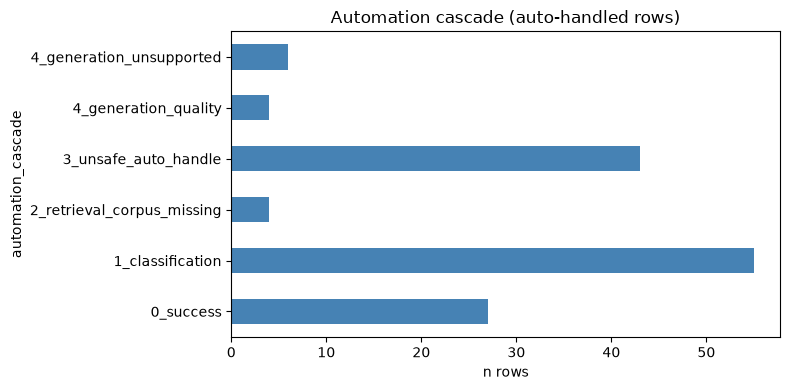

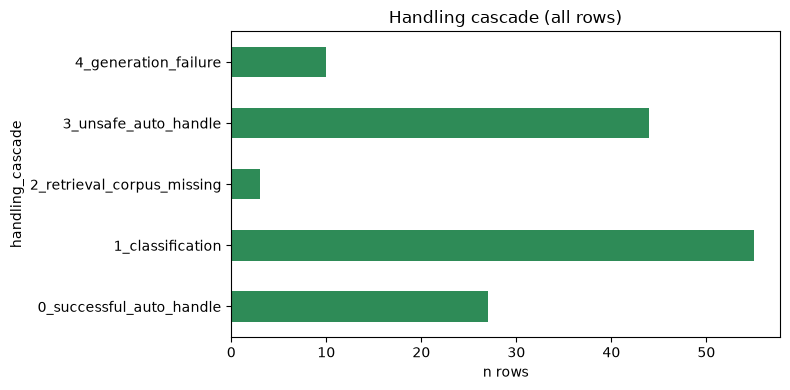

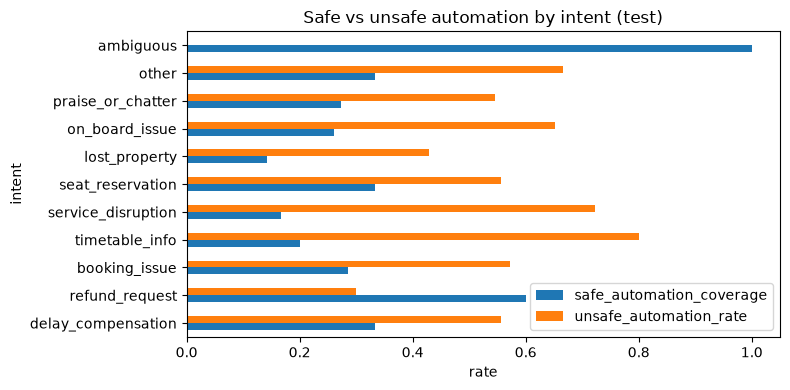

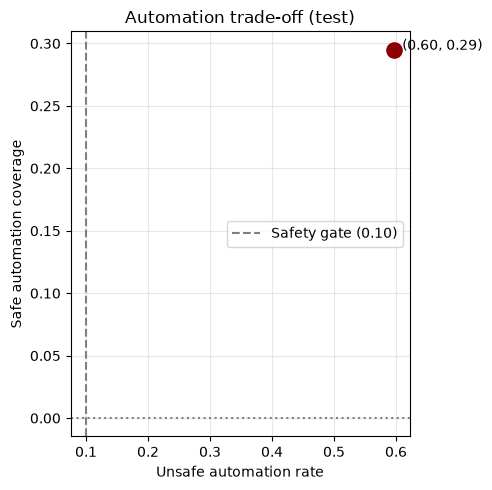

Figures written to reports/figures/


In [19]:
# ============ CELL 9: Consolidated metrics + report artifacts ============

# --- Corpus size from frozen corpus ---
corpus_size = 0
with open(RET_CORPUS, "r", encoding="utf-8") as f:
    for _ in f:
        corpus_size += 1

# --- metrics.json ---
metrics = {
    "notebook": "07_evaluation",
    "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "frozen_inputs": {
        "taxonomy_sha256":     tax_sha,
        "golden_sha256":       golden_sha,
        "classifier_sha256":   cls_chosen_sha,
        "retriever_sha256":    ret_chosen_sha,
        "agent_sha256":        agent_chosen_sha,
        "corpus_sha256":       CORPUS_SHA,
    },
    "final_system": {
        "classifier":        cls_final["approach"],
        "retriever":         ret_final["approach"],
        "agent":             ag_final["chosen_approach"],
        "generator_model":   agent_chosen.get("generator_model"),
        "judge_model":       agent_chosen.get("judge_model"),
        "escalation_config": agent_chosen.get("escalation_config"),
    },
    "n_test": int(len(end)),
    "corpus_size": corpus_size,
    "q1_grounding_dev": {
        "delta_universal":   delta_grounding,
        "delta_unsupported": delta_unsupported,
        "note": "DEV-only ablation from 06. Not re-evaluated on test.",
    },
    "q2_generation_test": {
        "mean_universal_auto":   mean_universal,
        "unsupported_rate_auto": unsup_rate,
        "n_replies":             reply_n,
    },
    "q3_automation_test": {
        "automation_coverage":       auto_n / len(end),
        "automation_coverage_denom": len(end),
        "safe_automation_coverage":  safe_auto_coverage,
        "safe_automation_denom":     len(end),
        "unsafe_automation_rate":    unsafe_auto_rate,
        "unsafe_automation_denom":   auto_n,
        "escalation_precision":      escalation_precision,
        "escalation_recall":         escalation_recall,
        "decision_accuracy":         decision_accuracy,
        "escalation_tp":             tp,
        "escalation_fp":             fp,
        "escalation_tn":             tn,
        "escalation_fn":             fn,
    },
    "pipeline_success": {
        "safe_handling_rate":    safe_handling_rate,
        "safe_automation_rate":  safe_auto_coverage,
    },
    "confidence_intervals": {
        "classifier_accuracy_95ci":  list(ci_class_acc),
        "retrieval_recall@5_95ci":   list(ci_retrieval_r5),
        "universal_score_95ci":      list(ci_universal),
        "safe_automation_cov_95ci":  list(ci_safe_auto_cov),
        "unsafe_automation_95ci":    list(ci_unsafe_auto),
        "safe_handling_95ci":        list(ci_safe_handling),
    },
    "upstream_headlines": {
        "classifier_op_macro_f1": cls_final["operational"]["macro_f1"],
        "retrieval_recall@5":     ret_final["metrics"]["recall@5"],
        "retrieval_mrr":          ret_final["metrics"]["mrr"],
    },
    "human_audit": {
        "retrieval_ndcg@5":     ret_chosen.get("human_audit_diagnostic", {}).get("ndcg_at_5"),
        "retrieval_graded_p@5": ret_chosen.get("human_audit_diagnostic", {}).get("graded_precision_at_5_ge1"),
    },
    "cost_latency": {
        "note": "Not captured in this run. Generation and judging use cache; "
                "token counts and latency were not aggregated by 06.",
    },
}

# Attach judge-human agreement from 06 spot-check if available
spot_path = RUNS_AGENT / "human_spot_check.csv"
if spot_path.exists():
    spot = pd.read_csv(spot_path, encoding="utf-8")
    def _nn(s): return s.notna() & (s.astype(str).str.strip() != "")
    graded = spot[_nn(spot["human_universal_score"])]
    auto_l = spot[_nn(spot["human_auto_handle_safe"])]
    if len(graded) >= 3:
        try:
            from scipy.stats import spearmanr
            j = graded["judge_universal_score"].astype(float)
            h = graded["human_universal_score"].astype(float)
            rho, _ = spearmanr(j, h)
            metrics["human_audit"]["agent_judge_universal_rho"] = float(rho)
            metrics["human_audit"]["agent_judge_universal_mad"] = float((j - h).abs().mean())
        except Exception:
            pass
    if len(auto_l) >= 3:
        h = auto_l["human_auto_handle_safe"].astype(str).str.lower().isin(
            ["y", "yes", "1", "true"])
        j = auto_l["judge_auto_handle_safe"].astype(bool)
        metrics["human_audit"]["agent_judge_esc_agreement"] = float((h == j).mean())

(RUNS_EVAL / "metrics.json").write_text(
    json.dumps(metrics, indent=2, default=str),
    encoding="utf-8",
)
print("Wrote metrics.json")

# --- Headline table ---
headline_rows = [
    ("Test n",                                     f"{len(end)}"),
    ("Classifier op macro F1 (test)",
     f"{cls_final['operational']['macro_f1']:.3f}"),
    ("Retrieval recall@5 (test)",
     f"{ret_final['metrics']['recall@5']:.3f}"),
    ("Mean universal score (test)",
     f"{mean_universal:.3f} [95% CI {ci_universal[0]:.2f}–{ci_universal[1]:.2f}]  n={reply_n}"),
    ("Unsupported-claim rate (test)",
     f"{unsup_rate:.3f}  n={reply_n}"),
    ("Automation coverage (test)",
     f"{auto_n/len(end):.3f}  n={len(end)}"),
    ("Safe automation coverage (test)",
     f"{safe_auto_coverage:.3f} [95% CI {ci_safe_auto_cov[0]:.2f}–{ci_safe_auto_cov[1]:.2f}]  n={len(end)}"),
    ("Unsafe automation rate (test)",
     f"{unsafe_auto_rate:.3f} [95% CI {ci_unsafe_auto[0]:.2f}–{ci_unsafe_auto[1]:.2f}]  n={auto_n}"),
    ("Safe-handling rate (test)",
     f"{safe_handling_rate:.3f} [95% CI {ci_safe_handling[0]:.2f}–{ci_safe_handling[1]:.2f}]  n={len(end)}"),
    ("Escalation precision (test)",
     f"{escalation_precision}" if escalation_precision is not None else "n/a"),
    ("Escalation recall (test)",
     f"{escalation_recall}" if escalation_recall is not None else "n/a"),
]
headline_df = pd.DataFrame(headline_rows, columns=["metric", "value"])
headline_df.to_csv(RUNS_EVAL / "table_headline.csv", index=False,
                   quoting=1, encoding="utf-8")

# --- Cascade table ---
cascade_df = pd.DataFrame({
    "stage":       ["1_classification", "2_retrieval_corpus_missing",
                    "3_unsafe_auto_handle", "4_generation_quality",
                    "4_generation_unsupported", "0_success"],
    "automation":  [int(auto_casc.get(k, 0)) for k in
                    ["1_classification", "2_retrieval_corpus_missing",
                     "3_unsafe_auto_handle", "4_generation_quality",
                     "4_generation_unsupported", "0_success"]],
})
cascade_df.to_csv(RUNS_EVAL / "table_cascade.csv", index=False,
                  quoting=1, encoding="utf-8")

# --- Limitations (dynamic values) ---
human_audit = ret_chosen.get("human_audit_diagnostic", {})
limitations_md = f"""# Limitations

- **Test set size (n={len(end)}).** Bootstrap 95% CIs reported on headline
  quantities. Small-class metrics (e.g. `ambiguous`, n=1) have wide CIs.
- **Coverage-oriented golden sampling.** Rare intents oversampled.
  Natural-slice metrics are the closest proxy for production traffic.
- **Intent-match retrieval relevance.** A 20-query human audit on dev found
  nDCG@5 = {human_audit.get('ndcg_at_5', 'n/a')} and graded P@5 = {human_audit.get('graded_precision_at_5_ge1', 'n/a')},
  indicating the proxy overstates usefulness.
- **Judge model is an LLM.** 20-row human spot-check: universal ρ = {metrics['human_audit'].get('agent_judge_universal_rho', 'n/a')}, escalation agreement = {metrics['human_audit'].get('agent_judge_esc_agreement', 'n/a')}.
- **Corpus scale.** {corpus_size} documents at smoke-test scale.
- **Historical responses may contain outdated policies.** Retrieval and
  grounding use historical GWRHelp replies without a time-relevance filter.
- **Escalation policy signals.** Classifier confidence and retrieval coverage
  do not discriminate safe from unsafe messages on dev.
- **Cost/latency not captured.**
"""
(RUNS_EVAL / "limitations.md").write_text(limitations_md, encoding="utf-8")
print("Wrote limitations.md")

# --- Figures ---
fig, ax = plt.subplots(figsize=(8, 4))
auto_casc.sort_index().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("n rows")
ax.set_title("Automation cascade (auto-handled rows)")
plt.tight_layout()
plt.savefig(REPORTS_FIGS / "pipeline_cascade_test.png", dpi=120)
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(8, 4))
hand_casc.sort_index().plot.barh(ax=ax, color="seagreen")
ax.set_xlabel("n rows")
ax.set_title("Handling cascade (all rows)")
plt.tight_layout()
plt.savefig(REPORTS_FIGS / "pipeline_handling_cascade_test.png", dpi=120)
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(8, 4))
per_intent_df.set_index("intent")[
    ["safe_automation_coverage", "unsafe_automation_rate"]
].plot.barh(ax=ax)
ax.set_xlabel("rate")
ax.set_title("Safe vs unsafe automation by intent (test)")
plt.tight_layout()
plt.savefig(REPORTS_FIGS / "automation_by_intent_test.png", dpi=120)
plt.show()
plt.close()

# --- Trade-off figure ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter([unsafe_auto_rate], [safe_auto_coverage], s=120,
           color="darkred", zorder=3)
ax.annotate(f"  ({unsafe_auto_rate:.2f}, {safe_auto_coverage:.2f})",
            (unsafe_auto_rate, safe_auto_coverage), fontsize=10)
ax.axvline(0.10, linestyle="--", color="gray", label="Safety gate (0.10)")
ax.axhline(0.0, linestyle=":", color="gray")
ax.set_xlabel("Unsafe automation rate")
ax.set_ylabel("Safe automation coverage")
ax.set_title("Automation trade-off (test)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_FIGS / "automation_tradeoff_test.png", dpi=120)
plt.show()
plt.close()

print("Figures written to reports/figures/")

In [20]:
# ============ CELL 10: Artifact manifest ============
MANIFEST = RUNS_EVAL / "artifact_manifest.json"
files = []
for path in sorted(RUNS_EVAL.rglob("*")):
    if path.is_file() and path.name != "artifact_manifest.json":
        files.append({
            "path":       str(path.relative_to(PROJECT_ROOT)),
            "size_bytes": path.stat().st_size,
            "sha256":     hashlib.sha256(path.read_bytes()).hexdigest(),
        })
MANIFEST.write_text(json.dumps({
    "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "artifacts":  files,
}, indent=2), encoding="utf-8")
print(f"Wrote artifact_manifest.json ({len(files)} files)")
for f in files:
    print(f"  {f['path']}  ({f['size_bytes']} B)")

Wrote artifact_manifest.json (12 files)
  runs\evaluation\end_to_end_test.jsonl  (153976 B)
  runs\evaluation\failure_cases_test.csv  (7867 B)
  runs\evaluation\failure_mode_counts.csv  (236 B)
  runs\evaluation\limitations.md  (958 B)
  runs\evaluation\metrics.json  (3196 B)
  runs\evaluation\table_cascade.csv  (188 B)
  runs\evaluation\table_confusion_pairs.csv  (418 B)
  runs\evaluation\table_decisions_by_intent.csv  (414 B)
  runs\evaluation\table_headline.csv  (551 B)
  runs\evaluation\table_length_bins.csv  (232 B)
  runs\evaluation\table_per_intent.csv  (1367 B)
  runs\evaluation\table_slices.csv  (649 B)


In [21]:
# ============ CELL 11: Handoff to report ============
handoff = {
    "from_notebook": "07_evaluation.ipynb",
    "to_artifact":   "reports/final_report.md",
    "consumes": [
        "runs/evaluation/metrics.json",
        "runs/evaluation/table_headline.csv",
        "runs/evaluation/table_cascade.csv",
        "runs/evaluation/table_per_intent.csv",
        "runs/evaluation/table_slices.csv",
        "runs/evaluation/table_length_bins.csv",
        "runs/evaluation/table_decisions_by_intent.csv",
        "runs/evaluation/table_confusion_pairs.csv",
        "runs/evaluation/failure_mode_counts.csv",
        "runs/evaluation/failure_cases_test.csv",
        "runs/evaluation/limitations.md",
        "reports/figures/pipeline_cascade_test.png",
        "reports/figures/pipeline_handling_cascade_test.png",
        "reports/figures/automation_by_intent_test.png",
        "reports/figures/automation_tradeoff_test.png",
    ],
    "metrics_sha256": hashlib.sha256(
        (RUNS_EVAL / "metrics.json").read_bytes()
    ).hexdigest(),
    "note": ("Every number in reports/final_report.md must trace to "
             "runs/evaluation/metrics.json or one of the table_*.csv files."),
}
(RUNS_EVAL / "handoff_to_report.json").write_text(
    json.dumps(handoff, indent=2), encoding="utf-8"
)

print("=" * 72)
print("07 — EVALUATION SUMMARY")
print("=" * 72)
print()
print(f"Classifier op macro F1 (test):  {cls_final['operational']['macro_f1']:.3f}")
print(f"Retrieval recall@5 (test):       {ret_final['metrics']['recall@5']:.3f}")
print(f"Mean universal score (test):     {mean_universal:.3f}  (n={reply_n})")
print(f"Unsupported-claim rate:          {unsup_rate:.3f}")
print()
print(f"Automation coverage:             {auto_n/len(end):.3f}")
print(f"Safe automation coverage:        {safe_auto_coverage:.3f}")
print(f"Unsafe automation rate:          {unsafe_auto_rate:.3f}")
print(f"Safe-handling rate:              {safe_handling_rate:.3f}")
print()
print(f"Handoff written:                 {RUNS_EVAL / 'handoff_to_report.json'}")
print(f"Artifacts:                       {len(files)} files")

07 — EVALUATION SUMMARY

Classifier op macro F1 (test):  0.624
Retrieval recall@5 (test):       0.532
Mean universal score (test):     13.374  (n=139)
Unsupported-claim rate:          0.194

Automation coverage:             1.000
Safe automation coverage:        0.295
Unsafe automation rate:          0.597
Safe-handling rate:              0.201

Handoff written:                 D:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\evaluation\handoff_to_report.json
Artifacts:                       12 files
